<a href="https://colab.research.google.com/github/Joyasree462/Computer-Graphics-and-Image-Processing/blob/main/Lab_2_Scan_Conversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter x1: 0
Enter y1: 0
Enter x2: 8
Enter y2: 16

--- Direct line equation method ---
Starting Point: (0, 0)
Ending Point: (8, 16)
Slope: 2.0
Y-intercept: 0.0
Case: Step Line.

x = 0
y = 0
pixels -> (0, 0)
x = 0
y = 1
pixels -> (0, 1)
x = 1
y = 2
pixels -> (1, 2)
x = 2
y = 3
pixels -> (2, 3)
x = 2
y = 4
pixels -> (2, 4)
x = 2
y = 5
pixels -> (2, 5)
x = 3
y = 6
pixels -> (3, 6)
x = 4
y = 7
pixels -> (4, 7)
x = 4
y = 8
pixels -> (4, 8)
x = 4
y = 9
pixels -> (4, 9)
x = 5
y = 10
pixels -> (5, 10)
x = 6
y = 11
pixels -> (6, 11)
x = 6
y = 12
pixels -> (6, 12)
x = 6
y = 13
pixels -> (6, 13)
x = 7
y = 14
pixels -> (7, 14)
x = 8
y = 15
pixels -> (8, 15)
x = 8
y = 16
pixels -> (8, 16)


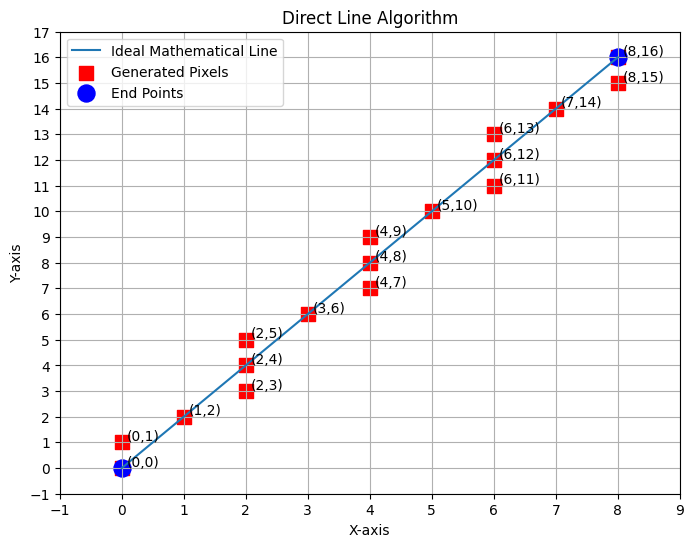

In [2]:
###Direct Line ###

import matplotlib.pyplot as plt
def direct_line(x1, y1, x2, y2):
    pixels = []

    print("\n--- Direct line equation method ---")
    print("Starting Point:", (x1, y1))
    print("Ending Point:", (x2, y2))

    dx = x2 - x1
    dy = y2 - y1

    # For only vertical Line
    if dx == 0:
        print("Case: Vertical Line.\n")
        print("Slope is undefined.\n")

        start_y = min(y1, y2)
        end_y = max(y1, y2)

        for y in range(start_y, end_y + 1):
            pixels.append((x1, y))

    # For horizontal or non-vertical Line
    else:
        m = dy / dx
        b = y1 - m * x1

        print("Slope:", m)
        print("Y-intercept:", b)

        # Shallow Line
        if abs(m) <= 1:
            print("Case: Shallow Line.\n")

            start_x = min(x1, x2)
            end_x = max(x1, x2)

            for x in range(start_x, end_x + 1):
                y = m * x + b
                round_y = round(y)

                pixels.append((x, round_y))

                print("x =", x)
                print("y =", round_y)
                print("pixels ->", (x, round_y))

        # Step / Steep Line
        else:
            print("Case: Step Line.\n")

            start_y = min(y1, y2)
            end_y = max(y1, y2)

            for y in range(start_y, end_y + 1):
                x = (y - b) / m
                round_x = round(x)

                pixels.append((round_x, y))

                print("x =", round_x)
                print("y =", y)
                print("pixels ->", (round_x, y))

    return pixels

    ### Main Program ###

# Enter Coordinates

x1 = int(input("Enter x1: "))
y1 = int(input("Enter y1: "))
x2 = int(input("Enter x2: "))
y2 = int(input("Enter y2: "))

## calling function
pixels=direct_line(x1,y1,x2,y2)

import matplotlib.pyplot as plt

# Plotting Pixels

x_pixels = [p[0] for p in pixels]
y_pixels = [p[1] for p in pixels]

plt.figure(figsize=(8, 6))

# Ideal Mathematical Line
plt.plot(
    [x1, x2],
    [y1, y2],
    label="Ideal Mathematical Line"
)

# Generated Pixels
plt.scatter(
    x_pixels,
    y_pixels,
    s=100,
    marker="s",
    color="red",
    label="Generated Pixels"
)

# End Points
plt.scatter(
    [x1, x2],
    [y1, y2],
    s=150,
    marker="o",
    color="blue",
    label="End Points"
)

# Pixel coordinate labels
for x, y in pixels:
    plt.text(
        x + 0.08,
        y + 0.08,
        f"({x},{y})",
        fontsize=10
    )

plt.xticks(range(min(x1, x2) - 1, max(x1, x2) + 2))
plt.yticks(range(min(y1, y2) - 1, max(y1, y2) + 2))

plt.grid(True)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Direct Line Algorithm")
plt.legend()
plt.show()




Enter x1: 0
Enter y1: 0
Enter x2: 6
Enter y2: 8

--- DDA Line Drawing Algorithm ---
Starting Point: (0, 0)
Ending Point: (6, 8)
Delta X = 6
Delta Y = 8
Slope (m) = 1.3333333333333333

Case 2: |Delta X| < |Delta Y|
x = 1
y = 1
pixels -> (1, 1)
x = 2
y = 2
pixels -> (2, 2)
x = 2
y = 3
pixels -> (2, 3)
x = 3
y = 4
pixels -> (3, 4)
x = 4
y = 5
pixels -> (4, 5)
x = 4
y = 6
pixels -> (4, 6)
x = 5
y = 7
pixels -> (5, 7)
x = 6
y = 8
pixels -> (6, 8)


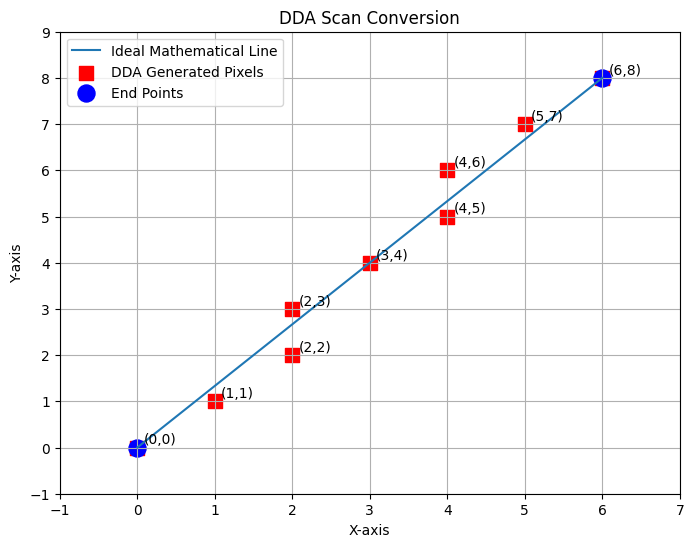

In [3]:
### Digital Differential Analyzer(DDA)

import matplotlib.pyplot as plt


def DDA_line(x1, y1, x2, y2):
    pixels = []

    print("\n--- DDA Line Drawing Algorithm ---")
    print("Starting Point:", (x1, y1))
    print("Ending Point:", (x2, y2))

    # Calculate delta x and delta y
    dx = x2 - x1
    dy = y2 - y1

    print("Delta X =", dx)
    print("Delta Y =", dy)

    # Vertical Line
    if dx == 0:
        print("\nCase: Vertical Line")

        step_y = 1 if dy > 0 else -1

        x = x1
        y = y1

        pixels.append((round(x), round(y)))

        while y != y2:
            y = y + step_y
            pixels.append((round(x), round(y)))

            print("x =", round(x))
            print("y =", round(y))
            print("pixels ->", (round(x), round(y)))

    else:
        # Calculate slope
        m = dy / dx

        print("Slope (m) =", m)

        # Case 1: |delta x| >= |delta y|
        if abs(dx) >= abs(dy):
            print("\nCase 1: |Delta X| >= |Delta Y|")

            # Delta X = 1 or -1
            step_x = 1 if dx > 0 else -1

            # x(i+1) = xi + Delta X
            # y(i+1) = yi + m * Delta X

            x = x1
            y = y1

            pixels.append((round(x), round(y)))

            while round(x) != x2:
                x = x + step_x
                y = y + m * step_x

                pixels.append((round(x), round(y)))

                print("x =", round(x))
                print("y =", round(y))
                print("pixels ->", (round(x), round(y)))

        # Case 2: |delta x| < |delta y|
        else:
            print("\nCase 2: |Delta X| < |Delta Y|")

            # Delta Y = 1 or -1
            step_y = 1 if dy > 0 else -1

            # x(i+1) = xi + Delta Y / m
            # y(i+1) = yi + Delta Y

            x = x1
            y = y1

            pixels.append((round(x), round(y)))

            while round(y) != y2:
                y = y + step_y
                x = x + step_y / m

                pixels.append((round(x), round(y)))

                print("x =", round(x))
                print("y =", round(y))
                print("pixels ->", (round(x), round(y)))

    return pixels

### Main Program ###

x1 = int(input("Enter x1: "))
y1 = int(input("Enter y1: "))
x2 = int(input("Enter x2: "))
y2 = int(input("Enter y2: "))

# Call DDA function
pixels = DDA_line(x1, y1, x2, y2)

### Plotting ###

x_pixels = [p[0] for p in pixels]
y_pixels = [p[1] for p in pixels]

plt.figure(figsize=(8, 6))

# Ideal mathematical line
plt.plot(
    [x1, x2],
    [y1, y2],
    label="Ideal Mathematical Line"
)

# Generated pixels
plt.scatter(
    x_pixels,
    y_pixels,
    s=100,
    marker="s",
    color="red",
    label="DDA Generated Pixels"
)

# End points
plt.scatter(
    [x1, x2],
    [y1, y2],
    s=150,
    marker="o",
    color="blue",
    label="End Points"
)

# Pixel coordinate labels
for x, y in pixels:
    plt.text(
        x + 0.08,
        y + 0.08,
        f"({x},{y})",
        fontsize=10
    )

plt.xticks(range(min(x1, x2) - 1, max(x1, x2) + 2))
plt.yticks(range(min(y1, y2) - 1, max(y1, y2) + 2))

plt.grid(True)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("DDA Scan Conversion")
plt.legend()
plt.show()

Enter x1: 9
Enter y1: 18
Enter x2: 14
Enter y2: 22

--- Bresenham's Straight Line Algorithm ---
Starting Point: (9, 18)
Ending Point: (14, 22)
Delta X = 5
Delta Y = 4
Initial Decision Parameter P = 3

Starting Pixel -> (9, 18)

Case 2: P >= 0
x = 10
y = 19
P = 1
pixels -> (10, 19)

Case 2: P >= 0
x = 11
y = 20
P = -1
pixels -> (11, 20)

Case 1: P < 0
x = 12
y = 20
P = 7
pixels -> (12, 20)

Case 2: P >= 0
x = 13
y = 21
P = 5
pixels -> (13, 21)

Case 2: P >= 0
x = 14
y = 22
P = 3
pixels -> (14, 22)


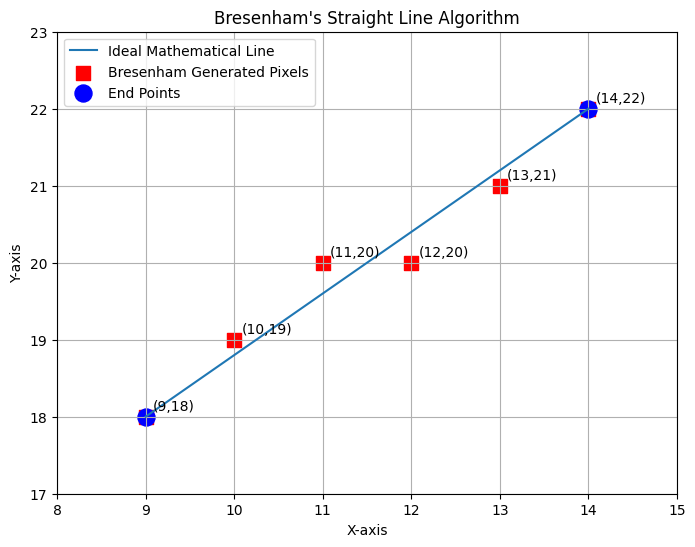

In [5]:
### Bresenham’s Straight Line Algorithm ###

import matplotlib.pyplot as plt


def bresenham_line(x1, y1, x2, y2):
    pixels = []

    print("\n--- Bresenham's Straight Line Algorithm ---")
    print("Starting Point:", (x1, y1))
    print("Ending Point:", (x2, y2))

    # Calculate Delta X and Delta Y
    dx = x2 - x1
    dy = y2 - y1

    print("Delta X =", dx)
    print("Delta Y =", dy)

    # Initial Decision Parameter
    p = 2 * dy - dx

    print("Initial Decision Parameter P =", p)

    # Starting point
    x = x1
    y = y1

    pixels.append((x, y))

    print("\nStarting Pixel ->", (x, y))

    # Repeat until ending point
    while x < x2:

        # Case 1: P < 0
        if p < 0:
            print("\nCase 1: P < 0")

            x = x + 1
            y = y

            # P(k+1) = P(k) + 2 Delta Y
            p = p + 2 * dy

        # Case 2: P >= 0
        else:
            print("\nCase 2: P >= 0")

            x = x + 1
            y = y + 1

            # P(k+1) = P(k) + 2 Delta Y - 2 Delta X
            p = p + 2 * dy - 2 * dx

        pixels.append((x, y))

        print("x =", x)
        print("y =", y)
        print("P =", p)
        print("pixels ->", (x, y))

    return pixels


### Main Program ###

x1 = int(input("Enter x1: "))
y1 = int(input("Enter y1: "))
x2 = int(input("Enter x2: "))
y2 = int(input("Enter y2: "))

# Call Bresenham function
pixels = bresenham_line(x1, y1, x2, y2)


### Plotting ###

x_pixels = [p[0] for p in pixels]
y_pixels = [p[1] for p in pixels]

plt.figure(figsize=(8, 6))

# Ideal Mathematical Line
plt.plot(
    [x1, x2],
    [y1, y2],
    label="Ideal Mathematical Line"
)

# Generated Pixels
plt.scatter(
    x_pixels,
    y_pixels,
    s=100,
    marker="s",
    color="red",
    label="Bresenham Generated Pixels"
)

# End Points
plt.scatter(
    [x1, x2],
    [y1, y2],
    s=150,
    marker="o",
    color="blue",
    label="End Points"
)

# Pixel coordinate labels
for x, y in pixels:
    plt.text(
        x + 0.08,
        y + 0.08,
        f"({x},{y})",
        fontsize=10
    )

plt.xticks(range(min(x1, x2) - 1, max(x1, x2) + 2))
plt.yticks(range(min(y1, y2) - 1, max(y1, y2) + 2))

plt.grid(True)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Bresenham's Straight Line Algorithm")
plt.legend()
plt.show()

Enter Radius: 9

--- Bresenham's Circle Algorithm ---
Radius: 9
Initial x = 0
Initial y = 9
Initial P = -15

Current Point: (0, 9)
P = -15
Case 1: P < 0
Next x = 1
Next y = 9
Next P = -5

Current Point: (1, 9)
P = -5
Case 1: P < 0
Next x = 2
Next y = 9
Next P = 9

Current Point: (2, 9)
P = 9
Case 2: P >= 0
Next x = 3
Next y = 8
Next P = -1

Current Point: (3, 8)
P = -1
Case 1: P < 0
Next x = 4
Next y = 8
Next P = 21

Current Point: (4, 8)
P = 21
Case 2: P >= 0
Next x = 5
Next y = 7
Next P = 23

Current Point: (5, 7)
P = 23
Case 2: P >= 0
Next x = 6
Next y = 6
Next P = 33

Current Point: (6, 6)
P = 33
Case 2: P >= 0
Next x = 7
Next y = 5
Next P = 51


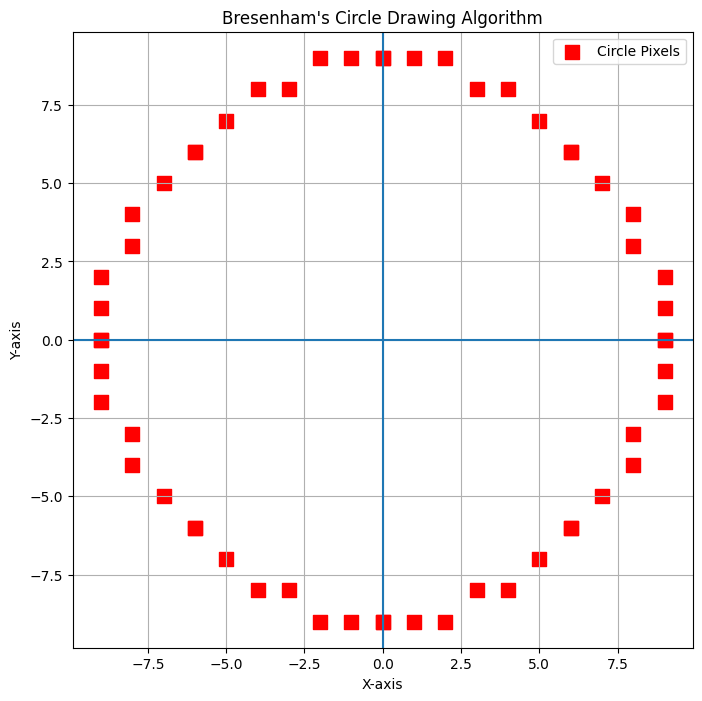

In [6]:
###Bresenham’s Circle Drawing Algorithm ###


import matplotlib.pyplot as plt


def bresenham_circle(R):
    pixels = []

    # Initial values
    x = 0
    y = R
    p = 3 - 2 * R

    print("\n--- Bresenham's Circle Algorithm ---")
    print("Radius:", R)
    print("Initial x =", x)
    print("Initial y =", y)
    print("Initial P =", p)

    # Generate points for one octant
    while x <= y:

        # 8 symmetric points
        pixels.append((x, y))
        pixels.append((-x, y))
        pixels.append((x, -y))
        pixels.append((-x, -y))
        pixels.append((y, x))
        pixels.append((-y, x))
        pixels.append((y, -x))
        pixels.append((-y, -x))

        print("\nCurrent Point:", (x, y))
        print("P =", p)

        # Case 1: P < 0
        if p < 0:
            print("Case 1: P < 0")

            # xi+1 = xi + 1
            x = x + 1

            # yi+1 = yi
            y = y

            # Pi+1 = Pi + 4xi + 6
            p = p + 4 * x + 6

        # Case 2: P >= 0
        else:
            print("Case 2: P >= 0")

            # xi+1 = xi + 1
            x = x + 1

            # yi+1 = yi - 1
            y = y - 1

            # Pi+1 = Pi + 4(xi - yi) + 10
            p = p + 4 * (x - y) + 10

        print("Next x =", x)
        print("Next y =", y)
        print("Next P =", p)

    return pixels


### Main Program ###

R = int(input("Enter Radius: "))

pixels = bresenham_circle(R)


### Plotting Circle ###

x_pixels = [p[0] for p in pixels]
y_pixels = [p[1] for p in pixels]

plt.figure(figsize=(8, 8))

plt.scatter(
    x_pixels,
    y_pixels,
    s=100,
    marker="s",
    color="red",
    label="Circle Pixels"
)

plt.axhline(0)
plt.axvline(0)

plt.grid(True)

plt.xlabel("X-axis")
plt.ylabel("Y-axis")

plt.title("Bresenham's Circle Drawing Algorithm")

plt.axis("equal")
plt.legend()

plt.show()